<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/movie_reviews_as_positive_or_negative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis on Movie Reviews
This notebook demonstrates building a Deep Learning model to classify movie reviews as positive or negative using the IMDb dataset.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import matplotlib.pyplot as plt

### 1. Load and Preprocess Data
We limit the vocabulary to the top 10,000 most frequent words and pad sequences so they all have the same length.

In [2]:
num_words = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

# Pad sequences to ensure uniform input size
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (25000, 200)
Testing data shape: (25000, 200)


### 2. Build the Model
We use an Embedding layer followed by an LSTM (Long Short-Term Memory) layer to capture sequential patterns in the text.

In [3]:
model = Sequential([
    Embedding(num_words, 128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 3. Train the Model
We'll train for a few epochs. Note: This may take a minute depending on the runtime.

In [4]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate on test set
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 305ms/step - accuracy: 0.7613 - loss: 0.4952 - val_accuracy: 0.8166 - val_loss: 0.4105
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 312ms/step - accuracy: 0.8592 - loss: 0.3440 - val_accuracy: 0.8380 - val_loss: 0.3838
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 300ms/step - accuracy: 0.8820 - loss: 0.2947 - val_accuracy: 0.8514 - val_loss: 0.3798
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 299ms/step - accuracy: 0.8924 - loss: 0.2799 - val_accuracy: 0.8452 - val_loss: 0.3891
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 296ms/step - accuracy: 0.8505 - loss: 0.3450 - val_accuracy: 0.8300 - val_loss: 0.3999
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.8268 - loss: 0.4127
Test Accuracy: 0.8268


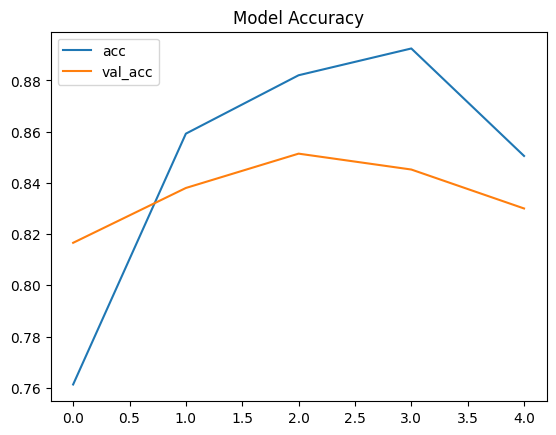

In [5]:
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()